In [1]:
import pandas as pd
import numpy as np

import matplotlib.pylab as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.shape

(20640, 9)

In [3]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


### Outlier handling using IQR

In [4]:
cols = df.drop(columns="MedHouseVal").columns
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (df[cols] >= lower_bound) & (df[cols] <= upper_bound)

dfc = df[mask.all(axis=1)]

In [5]:
X = dfc.drop(columns="MedHouseVal").values
y = dfc["MedHouseVal"]
y = np.log1p(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
pipe = Pipeline(
    [
        (
            "quantile",
            QuantileTransformer(
                output_distribution="normal",
            ),
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_depth=6,
                max_iter=800,
                min_samples_leaf=10,
                l2_regularization=0.1,
            ),
        ),
    ]
)

In [8]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('quantile', QuantileTransformer(output_distribution='normal')),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               learning_rate=0.05, max_depth=6,
                                               max_iter=800,
                                               min_samples_leaf=10))])

In [9]:
p = pd.DataFrame(pipe.predict(X_test))
p.shape

(3369, 1)

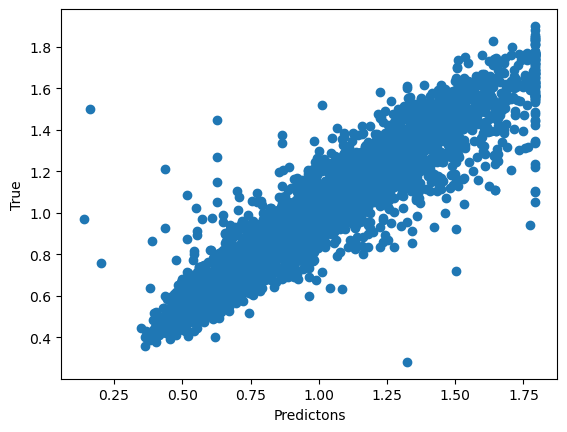

In [10]:
plt.scatter(y_test, p)

plt.xlabel("Predictons")
plt.ylabel("True")

plt.show()

In [11]:
from sklearn.metrics import r2_score

print(r2_score(y_test, p))

0.8487886355352791
